Simple U-NET Implementation

In [1]:
from enum import Enum
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
 
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from tqdm import trange, tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class MVTecADDataset(Dataset):

    def __init__(self, root_dir='datasets/pill'):
        super().__init__()
        self.root_dir = Path(root_dir)
        self.img_path = sorted(
            (self.root_dir / 'train' / 'good').glob('*.png')
        )

        self.transform = transforms.Compose([
            transforms.Resize((800, 800)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]
            )
        ]) 

    def __len__(self):
        return len(self.img_path)

    def __getitem__(self, index):
        path = self.img_path[index]

        image = Image.open(path).convert('RGB')
        image = self.transform(image)

        return image

Hyperparameters

In [4]:
lr = 1e-4
rgb = 3

state = 'pills.pth'



MVTec AD Dataset

metal_nut = 700 x 700
pill = 800 x 800
tile = 840 x 840
bottle = 900 x 900
capsule = 1000 x 1000
carpet = 1024 x 1024
grid = 1024 x 1024
leather = 1024 x 1024
wood = 1024 x 1024
cable = 1024 x 1024
screw = 1024 x 1024
tootkbrush = 1024 x 1024
transistor = 1024 x 1024
hazelnut = 1024 x 1024
zipper = 1024 x 1024


In [5]:
# metal_nut = 700
# pill = 800

In [6]:

# using MVTec AD dataset
# pill = 800 x 800

class SimpleUNET (nn.Module):

    def __init__(self):
        super().__init__()

        self.norm1 = nn.GroupNorm(24, 48)
        self.norm2 = nn.GroupNorm(32, 64)
        self.norm3 = nn.GroupNorm(32, 128)


        # (batch x 3 x 800 x 800)   sample size = 800 x 800
        # (batch x 3 x 1024 x 1024) sample size = 1024 x 1024
        self.downsamp1 = nn.Conv2d(
            in_channels=rgb, 
            out_channels=48,
            kernel_size=5, 
            padding=0, 
            stride=2,)
        # (batch x 48 x 398 x 398)
        # (batch x 48 x 510 x 510)
        self.downsamp2 = nn.Conv2d(
            in_channels=48,
            out_channels=64, 
            kernel_size=3, 
            padding=0, 
            stride=2)
        # (batch x 64 x 198 x 198)
        # (batch x 54 x 254 x 254)
        self.downsamp3 = nn.Conv2d(
            in_channels=64, 
            out_channels=128, 
            kernel_size=3, 
            padding=0, 
            stride=2)
        # (batch x 128 x 98 x 98)
        # (batch x 128 x 126 x 126)

        self.proj1 = nn.Conv2d(
            in_channels=128,
            out_channels=64,
            kernel_size=3,
            padding=1,
            stride=1
        )

        self.proj2 = nn.Conv2d(
            in_channels=96,
            out_channels=48,
            kernel_size=3,
            padding=1,
            stride=1
        )

        self.time_emb1 = nn.Linear(1, 48)
        # (1 x 24)
        self.time_emb2 = nn.Linear(1, 64)
        # (1 x 64)
        self.time_emb3 = nn.Linear(1, 128)
        # (1 x 128)

        self.bottleneck = nn.Sequential(
            nn.GroupNorm(32, 128),
            nn.SiLU(),
            # (batch x 128 x 98 x 98)
            nn.Conv2d(
                in_channels=128, 
                out_channels=128, 
                kernel_size=3, 
                padding=1,
                stride=1),
            nn.GroupNorm(32, 128),
            nn.SiLU(),
            # (batch x 128 x 98 x 98)
            nn.Conv2d(
                in_channels=128, 
                out_channels=128, 
                kernel_size=3, 
                padding=1,
                stride=1)
        )

        # (batch x 128 x 98 x 98) output_padding=1,  
        # (batch x 128 x 126 x126) output_padding=5
        self.upsamp4 = nn.ConvTranspose2d(
            in_channels=128, 
            out_channels=64, 
            kernel_size=3, 
            padding=0, 
            output_padding=1,
            stride=2)
        # (batch x 64 x 198 x 198) output_padding=1
        # (batch x 64 x 254 x 254) output_padding=5
        self.upsamp5 = nn.ConvTranspose2d(
            in_channels=64, 
            out_channels=48, 
            kernel_size=3, 
            padding=0,
            output_padding=1,
            stride=2)
        # (batch x 24 x 398 x 398) output_padding=1
        # (batch x 24 x 510 x 510) output_padding=7
        self.upsamp6 = nn.ConvTranspose2d(
            in_channels=48, 
            out_channels=rgb, 
            kernel_size=5, 
            padding=0, 
            output_padding=1,
            stride=2)
        # (batch x 3 x 800 x 800)
        # (batch x 3 x 1024 x 1024)


    def forward(self, x: torch.Tensor, t: torch.Tensor):

        # t = t.float()[:, None]
        # # (batch x 1)

        # down-sampling block
        # input
        # (batch x 3 x 800 x 800)


        h1 = self.downsamp1(x)
        # (batch x 24 x 398 x 398)
        h1 = self.norm1(h1)
        h1 = F.silu(h1)
        
        t1 = self.time_emb1(t)
        t1 = t1[:, :, None, None]
        # (batch x 24 x 1 x 1)
        # time-step conditioning
        h1 = h1 + t1

        h2 = self.downsamp2(h1)
        # (batch x 64 x 198 x 198)
        h2 = self.norm2(h2)
        h2 = F.silu(h2)
        
        t2 = self.time_emb2(t)
        t2 = t2[:, :, None, None]
        # (batch x 64 x 1 x 1)
        # time-step conditioning
        h2 = h2 + t2

        h3 = self.downsamp3(h2)
        # (batch x 144 x 98 x 98)
        h3 = self.norm3(h3)
        h3 = F.silu(h3)
        
        t3 = self.time_emb3(t)
        t3 = t3[:, :, None, None]
        # (batch x 144 x 1 x 1)
        # time-step conditioning
        h3 = h3 + t3

        # bottleneck

        # (batch x 144 x 98 x 98)
        latent = self.bottleneck(h3)
        # (batch x 144 x 98 x 98)


        # up-sampling block

        h4 = self.norm3(latent)
        h4 = F.silu(h4)
        h4 = self.upsamp4(h4)
        # (batch x 64 x 198 x 198)
        # time-step conditioning
        h4 = h4 + t2
        # skip connection
        # h4 and h2 have the same shape
        h4 = torch.concat([h4, h2], dim=1)
        # after skip (batch x 128 x 198 x 198)
        h4 = self.proj1(h4)
        # (batch x 64 x 198 x 198)

        h5 = self.norm2(h4)
        h5 = F.silu(h5)
        h5 = self.upsamp5(h5)
        # (batch x 24 x 398 x 398)
        # time-step conditioning
        h5 = h5 + t1
        # skip connection
        # h5 and h1 have the same shape
        h5 = torch.concat([h5, h1], dim=1)
        # after skip (batch x 48 x 398 x 398)
        h5 = self.proj2(h5)
        # (batch x 24 x 398 x 398)

        h6 = self.norm1(h5)
        h6 = F.silu(h6)
        h6 = self.upsamp6(h6)
        # (batch x 3 x 800 x 800)



        # predicted noise
        return h6





In [7]:
    # padding
    # valid = 0
    # same = 1

def conv_size(input: int, k:int, pad: int = 0, s:int=1):
    """
    input = in-channel
    k = kernel
    s = strise
    pad = padding
    """
    assert  k % 2, 'an odd number is preferred'

    return ((input + (2 * (pad * (k - 1))) - k) // s) + 1


def transpose_size(input, k, pad, s = 1, out=0, d=1):
    """
    input = in-channel
    k = kernel
    s = strise
    pad = padding
    oot = out-padding
    d =dilation
    """
    assert  k % 2, 'an odd number is preferred'

    return (input - 1) * s - (2 * pad) - (d * (k - 1)) + out + 1

In [8]:
conv_size(input=254, k=3, pad=0, s=2)

126

In [9]:
transpose_size(input=510, k=3, pad=0, out=7, s=2)

1024

### Training

$\epsilon$ = Noise

$\beta$ = amount of noise added to the sample

$\alpha = 1 - \beta$

$\alpha$ = Signal retention factor (measure of purity)

$\bar{\alpha}$ = The cumulative product of $\alpha$ 

$x_{t}$ = The magnitude of noise in the noisy sample

$x_{t} = \sqrt{\bar{\alpha}}x_{0} + \sqrt{1 - \bar{\alpha_{t}}}\epsilon$

In [10]:
def train(T, epochs, batch=4, beta_min=1e-4, beta_max=0.02, device='cuda', param_file='unet.pth'):

    dataset = MVTecADDataset()

    train_loader = DataLoader(
        dataset,
        batch_size=batch,
        shuffle=True
    )

    beta = torch.linspace(
        beta_min, 
        beta_max, # 2e-2
        T,
        device=device)


    alpha = 1 - beta

    alpha_bar = torch.cumprod(alpha, dim=0)
    # [T]

    model = SimpleUNET()
    model = model.to(device)

    checkpoint = Path(param_file)

    if checkpoint.exists():

        state_dict = torch.load(
            f=checkpoint,
            map_location=device,
            weights_only=True)
        model.load_state_dict(state_dict)

        print(f'Using parameters from checkpint: {checkpoint.name}')

    else:

        print('No checkpoint found, training from scratch')
        # torch.save(model.state_dict(), checkpoint)

    optimizer = optim.Adam(
        params=model.parameters(),
        lr=lr
    )

    model.train() 

    for epoch in trange(epochs):

        running_loss = 0.0

        for x0 in train_loader:
            x0 = x0.to(device)
            # current batch size
            shape = x0.shape[0]
            # random timestep
            ts = torch.randint(
                low=0,
                high=T,
                size=(shape,),
                device=device)
            # [b]
            alpha_bar_t = alpha_bar[ts]
            # [T] --> [b]
            alpha_bar_t = alpha_bar_t[:, None, None, None]
            # [b] --> [b x 1 x 1 x 1]
            # noise
            epsilon = torch.randn_like(x0)
            # noise data
            xt = (torch.sqrt(alpha_bar_t) * x0) + (torch.sqrt(1 - alpha_bar_t) * epsilon)
            # noise prediction
            # normalized 
            tmodel = ts.float()[:, None] / (T - 1)
            # predict noise
            epsilon_pred = model(xt, tmodel)

            loss = F.mse_loss(epsilon_pred, epsilon)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)

        print(
            f'Epoch {epoch + 1} / {epochs}',
            f'Loss: {average_loss:.6f}'
            # f'Running Loss:  {running_loss:.4f}',
            # f'loader len:  {len(train_loader)}'
        )

    torch.save(model.state_dict(), checkpoint)


    return model


In [11]:
def add_noise(img, beta: int):

    assert (beta <= 1) and (beta >= 0) , 'beta must be an integer between 0 and 1'

    epsilon = torch.randn_like(img)

    if beta == 1:

        return epsilon

    elif beta == 0:

        return img

    else:

        alpha = torch.tensor(1 - beta)

        # return (torch.sqrt(alpha) * img) + (torch.sqrt(1-alpha) * epsilon)
        return (alpha * img) + ((1-alpha) * epsilon)

In [12]:
torch.sqrt(torch.tensor(64))

tensor(8.)

The contional mean, expectation or the center of the probability distribution
$$\mathbb{E}[x_{t-1} \mid x_t] = \int x_{t-1}\, p(x_{t-1} \mid x_t)\, dx_{t-1}$$
mean → $\mu_\theta(x_t, t)$
$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\, \epsilon_\theta(x_t, t) \right)$$

In [13]:
@torch.inference_mode()
def test(x_in=None, beta_min=1e-4, beta_max=0.02, T=10000, batch=4, 
         params=None, device='cuda', shape=None, noise=1):
    """The function for inference, image generation and image restoration
    parameters:
    x_in : image, partially noisy 
    """

    assert 0 <= beta_min < beta_max < 1,'beta_min must be less than beta_max, and their range is [0, 1)'
    assert 0 <= noise <= 1, 'the value of noise has a range of [0, 1]' 

    betas = torch.linspace(
        start=beta_min,
        end=beta_max,
        steps=T,
        device=device
    )

    # fractile = T - 1

    alphas = 1 - betas

    alpha_bar = torch.cumprod(alphas, dim=0)

    if x_in is None:

        assert shape is not None, 'shape must be set to a tuple like so (3, 64, 64)'

        t_start = T - 1
        xt = torch.randn(batch, *shape, device=device)

    else:

        t_start = round(noise * (T - 1))
        x0 = x_in.to(device)
        epsilon = torch.randn_like(x0)
        xt = alpha_bar[t_start].sqrt() * x0 + (1 - alpha_bar[t_start]).sqrt() * epsilon
        

    model = SimpleUNET().to(device)

    if params is not None:
        state = torch.load(params, weights_only=True, map_location=device)
        model.load_state_dict(state)

    model.eval()

    tnorm = lambda t: t / (T - 1)

    for t in range(t_start, -1, -1):

        tmodel = torch.full((xt.shape[0], 1), tnorm(t), device=device)

        epsilon_pred = model(xt, tmodel)

        mean = (xt - (betas[t] / (1 - alpha_bar[t]).sqrt()) * epsilon_pred) / alphas[t].sqrt()

        z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)

        xt = mean  +  z * betas[t].sqrt()

    return xt.clamp(-1, 1)





    

In [14]:
# epochs = 20

# T = 40

# model = train(T, epochs, batch=4)

# torch.save(
#     model.state_dict(),
#     "simple_unet-2.pth"
# )

In [15]:
dataset = MVTecADDataset()

img = dataset[8]

batch = 4

epochs = 50

f = 'pills.pth'

T = 1000

model = train(T, epochs, batch, param_file=f)

# torch.save(model.state_dict(), 'pills.pth')



# end

Using parameters from checkpint: pills.pth


  2%|▏         | 1/50 [00:18<15:23, 18.84s/it]

Epoch 1 / 50 Loss: 0.014014


  4%|▍         | 2/50 [00:37<15:07, 18.90s/it]

Epoch 2 / 50 Loss: 0.015672


...

Epoch 48 / 50 Loss: 0.013083


 98%|█████████▊| 49/50 [16:30<00:20, 20.67s/it]

Epoch 49 / 50 Loss: 0.012189


100%|██████████| 50/50 [16:51<00:00, 20.22s/it]

Epoch 50 / 50 Loss: 0.012055


In [16]:
dataset = MVTecADDataset()

loader = DataLoader(dataset, batch_size=4)

data_iter = iter(loader)

image = next(data_iter)

# image = image.permute(1, 2, 0)

# img = add_noise(image, 0.005)

T = 1000

batch = 4

# shape = (3, 800, 800)
shape = img.shape


state = 'pills.pth'
output = test(
    x_in=image, 
    T=T, 
    noise=0.3,
    batch=batch, 
    shape=shape, 
    params=state, 
    device='cuda')

#end

In [17]:
# img = img.permute(1, 2, 0)

# plt.imshow(img)

# plt.axis('off')

# plt.show()

In [18]:
# seq = torch.unbind(output, dim=0)
# len(seq)

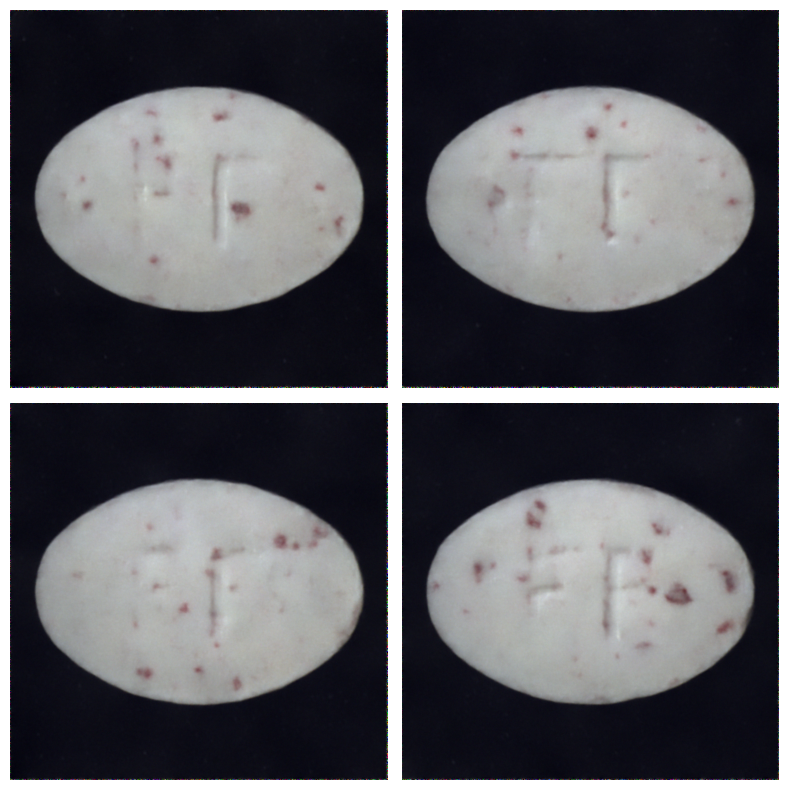

In [19]:

seq = torch.unbind(output, dim=0)
seq_size = len(seq)
rows = seq_size // 2
cols = 2
fig, ax = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))

ax = ax.flatten()

for i, img in enumerate(seq):

    img = ((img + 1) / 2).clamp(0, 1)
    img = img.permute(1, 2, 0).cpu().numpy()
    ax[i].imshow(img)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

# end



Test block

In [23]:
dataset = MVTecADDataset()
batch = 4

train_loader = DataLoader(
        dataset,
        batch_size=batch,
        shuffle=True
    )


n = len(train_loader)

T = 25

ts = torch.randint(
    low=0,
    high=T,
    size=(batch,)
    # device=device
)

print('the shape of ts: ', ts.shape)

beta = torch.linspace(
    0.0001, 
    0.02, 
    T)


alpha = 1 - beta

alpha_bar = torch.cumprod(alpha, dim=0)
# (67)

alpha_bar_t = alpha_bar[ts]
print(alpha_bar_t.shape)

alpha_bar = alpha_bar[:, None, None, None]
# (67 x 1 x 1 x 1)



print('size of train_loader: ', len(train_loader))
print('shape of alpha: ', alpha.shape)
print('shape of alpha_bar: ', alpha_bar.shape)
print(alpha_bar[[0,1,2,3]].shape)
print('the shape of ts: ', ts.shape)
print(ts[[2, 0, 1, 3]])
print(ts)
print(alpha_bar[ts])

the shape of ts:  torch.Size([4])
torch.Size([4])
size of train_loader:  67
shape of alpha:  torch.Size([25])
shape of alpha_bar:  torch.Size([25, 1, 1, 1])
torch.Size([4, 1, 1, 1])
the shape of ts:  torch.Size([4])
tensor([2, 2, 1, 1])
tensor([2, 1, 2, 1])
tensor([[[[0.9972]]],


        [[[0.9990]]],


        [[[0.9972]]],


        [[[0.9990]]]])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.81960785].


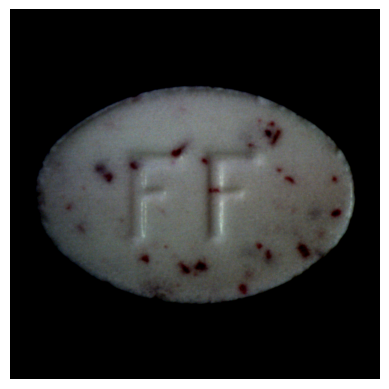

In [24]:
dataset = MVTecADDataset()

image = dataset[8]

image = image.permute(1, 2, 0)

img = add_noise(image, 0)

plt.imshow(img)

plt.axis('off')

plt.show()
